In [ ]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

# print(f"Numpy version: {np.__version__}")
# print(f"Pandas version: {pd.__version__}")
# print(f"Matplotlib version: {plt.matplotlib.__version__}")
# print(f"Scikit-learn version: {sklearn.__version__}")
# print(f"Seaborn version: {sns.__version__}")

Numpy version: 2.4.3
Pandas version: 3.0.1
Matplotlib version: 3.10.8
Scikit-learn version: 1.8.0
Seaborn version: 0.13.2


In [6]:
housing = fetch_california_housing()
print(housing)

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]], shape=(20640, 8)), 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)), 'frame': None, 'target_names': ['MedHouseVal'], 'feature_names': ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'], 'DESCR': '.. _california_housing_dataset

In [7]:
df = pd.DataFrame(housing.data, columns=housing.feature_names)
print(df)

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  
0        -122.23  
1

performing cleaning on Averoom cleaning

In [8]:
column = 'AveRooms'

In [10]:
# Calculate the first and third quartiles
Q1 = df[column].quantile(0.25)
Q3 = df[column].quantile(0.75)
print(f'Q1 = {Q1:.2f}')
print(f'Q3 = {Q3:.2f}')
# Calculate the interquartile range (IQR)
IQR = Q3 - Q1
print(f'IQR = {IQR:.2f}')
# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f'Lower Bound = {lower_bound:.2f}')
print(f'Upper Bound = {upper_bound:.2f}')

Q1 = 4.44
Q3 = 6.05
IQR = 1.61
Lower Bound = 2.02
Upper Bound = 8.47


Identifying and visualizing outliers

In [11]:
#Filter the DataFrame to find outliers
outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

print(f"Total rows: {len(df)}")
print(f"Outliers found or outliers rows: {len(outliers)}")

Total rows: 20640
Outliers found or outliers rows: 511


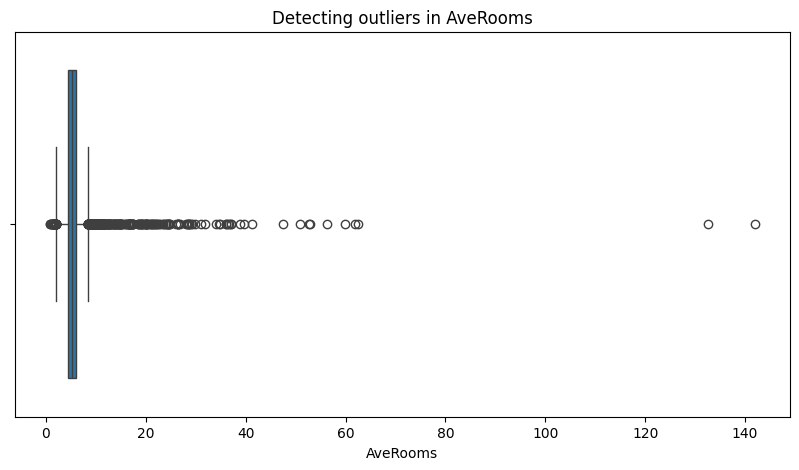

In [15]:
# visualize the boxplot
plt.figure(figsize=(10, 5)) #10 inches wide and 5 inches tall for the= canvas
sns.boxplot(x=df[column])
plt.title(f'Detecting outliers in {column}')
plt.show()

Remove outliers(Data cleaning)

In [16]:
# Keep only the non-outliers in the DataFrame i.e. data withim bounds
df_cleaned = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

print(f"shape before removing outliers: {df.shape}")
print(f"shape after removing outliers: {df_cleaned.shape}")

shape before removing outliers: (20640, 8)
shape after removing outliers: (20129, 8)


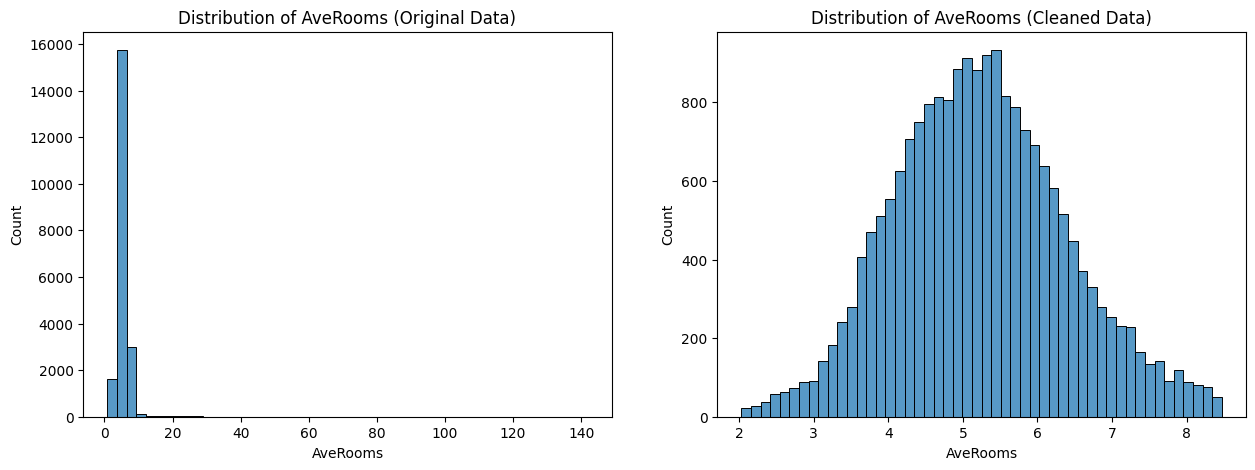

In [ ]:
#Compare distribution of the original and cleaned data
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
# subplots (1,2) creates a grid of 1 row and 2 columns for plotting
# figsize=(15,5) sets the size of the entire figure to 15 inches wide and 5 inches tall
# fig = overall canvas
# ax = array of individual subplots (axes[0] and axes[1])
sns.histplot(df[column], bins=50, ax=ax[0]) #bins = 50 divides the data into 50 equal-width bins/bars for the histogram
ax[0].set_title(f'Distribution of {column} (Original Data)')
sns.histplot(df_cleaned[column], bins=50, ax=ax[1]) #bins = 50 divides the data into 50 equal-width bins/bars for the histogram
ax[1].set_title(f'Distribution of {column} (Cleaned Data)')
plt.show()

In [25]:
dta = 'AveBedrms'

In [26]:
# Calculate the first and third quartiles
Q1 = df[dta].quantile(0.25)
Q3 = df[dta].quantile(0.75)
print(f'Q1 = {Q1:.2f}')
print(f'Q3 = {Q3:.2f}')
# Calculate the interquartile range (IQR)
IQR = Q3 - Q1
print(f'IQR = {IQR:.2f}')
# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f'Lower Bound = {lower_bound:.2f}')
print(f'Upper Bound = {upper_bound:.2f}')

Q1 = 1.01
Q3 = 1.10
IQR = 0.09
Lower Bound = 0.87
Upper Bound = 1.24


Total rows: 20640
Outliers found or outliers rows: 1424


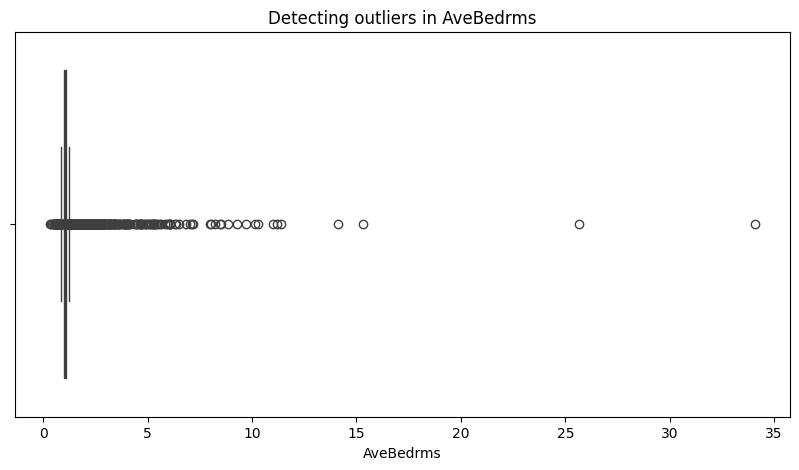

In [28]:
#Filter the DataFrame to find outliers
outliers = df[(df[dta] < lower_bound) | (df[dta] > upper_bound)]

print(f"Total rows: {len(df)}")
print(f"Outliers found or outliers rows: {len(outliers)}")

# visualize the boxplot
plt.figure(figsize=(10, 5)) #10 inches wide and 5 inches tall for the= canvas
sns.boxplot(x=df[dta])
plt.title(f'Detecting outliers in {dta}')
plt.show()

In [29]:
# Keep only the non-outliers in the DataFrame i.e. data withim bounds
df_cleaned = df[(df[dta] >= lower_bound) & (df[dta] <= upper_bound)]

print(f"shape before removing outliers: {df.shape}")
print(f"shape after removing outliers: {df_cleaned.shape}")

shape before removing outliers: (20640, 8)
shape after removing outliers: (19216, 8)


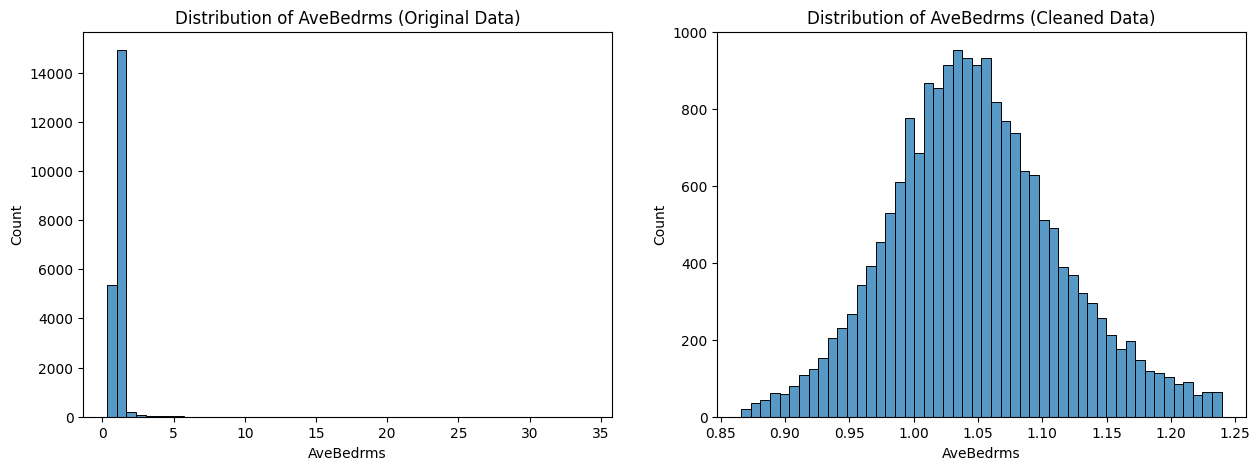

In [31]:
#Compare distribution of the original and cleaned data
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df[dta], bins=50, ax=ax[0]) #bins = 50 divides the data into 50 equal-width bins/bars for the histogram
ax[0].set_title(f'Distribution of {dta} (Original Data)')
sns.histplot(df_cleaned[dta], bins=50, ax=ax[1]) #bins = 50 divides the data into 50 equal-width bins/bars for the histogram
ax[1].set_title(f'Distribution of {dta} (Cleaned Data)')
plt.show()